In [ ]:
# IMPORT_PYTHON_LIBARY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# ADD_THE_CSV_FILE
df1= pd.read_csv('/content/delhi_traffic_features.csv')
df2= pd.read_csv('/content/delhi_traffic_target.csv')


In [ ]:
# SHOWING_THE_DELHI_TRAFFIC_FEATURE
df1

,Trip_ID,start_area,end_area,distance_km,time_of_day,day_of_week,weather_condition,traffic_density_level,road_type,average_speed_kmph
0,TRIP_00001,Vasant Kunj,Kalkaji,9.44,Night,Weekday,Clear,Low,Main Road,37.8
1,TRIP_00002,Greater Kailash,Kalkaji,2.15,Night,Weekend,Clear,Low,Main Road,42.7
2,TRIP_00003,Janakpuri,Model Town,14.54,Morning Peak,Weekday,Rain,High,Inner Road,9.7
3,TRIP_00004,Punjabi Bagh,Dwarka,11.86,Night,Weekday,Clear,Low,Highway,68.5
4,TRIP_00005,Rohini,Chandni Chowk,20.26,Afternoon,Weekday,Fog,Medium,Highway,30.3
...,...,...,...,...,...,...,...,...,...,...
3995,TRIP_03996,Rajouri Garden,Dwarka,9.64,Morning Peak,Weekday,Clear,Very High,Inner Road,7.7
3996,TRIP_03997,Rohini,Dwarka,17.53,Morning Peak,Weekend,Clear,High,Main Road,28.7
3997,TRIP_03998,Preet Vihar,Lajpat Nagar,9.58,Morning Peak,Weekend,Clear,High,Main Road,19.0
3998,TRIP_03999,Karol Bagh,Hauz Khas,11.44,Evening Peak,Weekend,Heatwave,High,Main Road,25.2


In [ ]:
# SHOWING_THE_DELHI_TRAFFIC_TARGET
df2

,Trip_ID,travel_time_minutes
0,TRIP_00001,15.3
1,TRIP_00002,3.0
2,TRIP_00003,92.7
3,TRIP_00004,10.6
4,TRIP_00005,42.0
...,...,...
3995,TRIP_03996,76.8
3996,TRIP_03997,37.2
3997,TRIP_03998,30.9
3998,TRIP_03999,27.6


In [ ]:
# COMBINE_BOTH_CSV
df = pd.merge(df1, df2, on="Trip_ID")
df

,Trip_ID,start_area,end_area,distance_km,time_of_day,day_of_week,weather_condition,traffic_density_level,road_type,average_speed_kmph,travel_time_minutes
0,TRIP_00001,Vasant Kunj,Kalkaji,9.44,Night,Weekday,Clear,Low,Main Road,37.8,15.3
1,TRIP_00002,Greater Kailash,Kalkaji,2.15,Night,Weekend,Clear,Low,Main Road,42.7,3.0
2,TRIP_00003,Janakpuri,Model Town,14.54,Morning Peak,Weekday,Rain,High,Inner Road,9.7,92.7
3,TRIP_00004,Punjabi Bagh,Dwarka,11.86,Night,Weekday,Clear,Low,Highway,68.5,10.6
4,TRIP_00005,Rohini,Chandni Chowk,20.26,Afternoon,Weekday,Fog,Medium,Highway,30.3,42.0
...,...,...,...,...,...,...,...,...,...,...,...
3995,TRIP_03996,Rajouri Garden,Dwarka,9.64,Morning Peak,Weekday,Clear,Very High,Inner Road,7.7,76.8
3996,TRIP_03997,Rohini,Dwarka,17.53,Morning Peak,Weekend,Clear,High,Main Road,28.7,37.2
3997,TRIP_03998,Preet Vihar,Lajpat Nagar,9.58,Morning Peak,Weekend,Clear,High,Main Road,19.0,30.9
3998,TRIP_03999,Karol Bagh,Hauz Khas,11.44,Evening Peak,Weekend,Heatwave,High,Main Road,25.2,27.6


In [ ]:
# DATA_CLEANING/CHECKING
clean1 = df1.isnull().sum()
# --------------------------------
print("------DELHI_TRAFFIC_FEATURE------")
print(clean1)


------DELHI_TRAFFIC_FEATURE------
Trip_ID                  0
start_area               0
end_area                 0
distance_km              0
time_of_day              0
day_of_week              0
weather_condition        0
traffic_density_level    0
road_type                0
average_speed_kmph       0
dtype: int64


In [ ]:
# DATA_CLEANING/CHECKING
clean1 = df1.duplicated().sum()
# --------------------------------
print("------DELHI_TRAFFIC_FEATURE------")
print(clean1)

------DELHI_TRAFFIC_FEATURE------
0


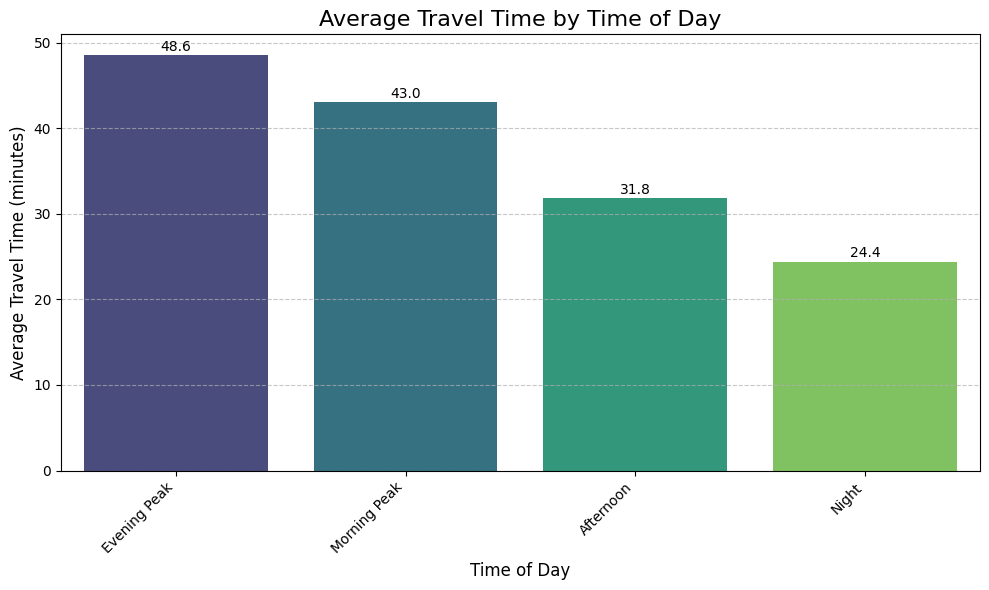

In [ ]:
# MAKING_VISUAL_FORMAT
# Average Travel Time by Time of Day
# -------------------------------------------------------------------------
travel_time_by_time_of_day = df.groupby("time_of_day")["travel_time_minutes"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=travel_time_by_time_of_day.index, y=travel_time_by_time_of_day.values, palette='viridis', hue=travel_time_by_time_of_day.index, legend=False)

plt.title('Average Travel Time by Time of Day', fontsize=16)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Average Travel Time (minutes)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)


for index, value in enumerate(travel_time_by_time_of_day.values):
    plt.text(index, value + 0.5, f'{value:.1f}', color='black', ha="center")

plt.tight_layout()
plt.show()

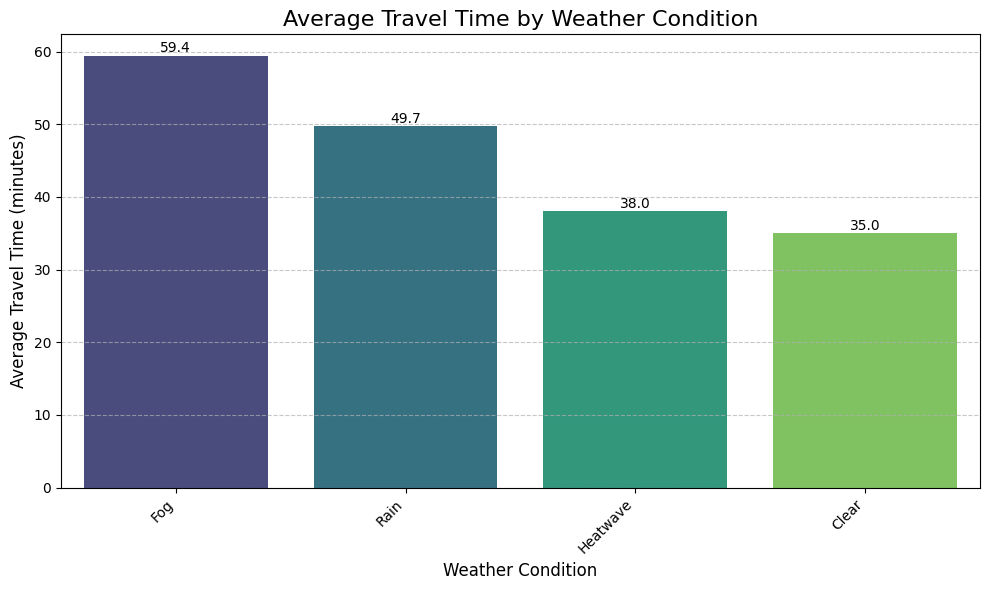

In [ ]:
# MAKING_VISUAL_FORMAT
# Average Travel Time by Weather Condition
# --------------------------------------------------------------------------------------
travel_time_by_weather_condition = df.groupby("weather_condition")["travel_time_minutes"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=travel_time_by_weather_condition.index, y=travel_time_by_weather_condition.values, palette='viridis', hue=travel_time_by_weather_condition.index, legend=False)

plt.title('Average Travel Time by Weather Condition', fontsize=16)
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Average Travel Time (minutes)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)


for index, value in enumerate(travel_time_by_weather_condition.values):
    plt.text(index, value + 0.5, f'{value:.1f}', color='black', ha="center")

plt.tight_layout()
plt.show()

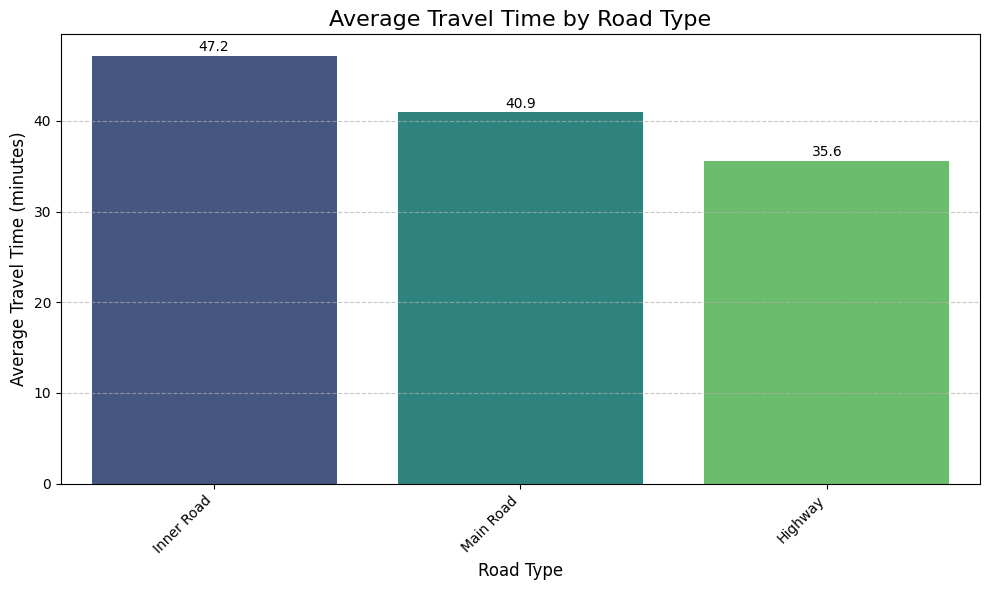

In [ ]:
# MAKING_VISUAL_FORMAT
# Average Travel Time by Road Type
# --------------------------------------------------------------------------------------
travel_time_by_road_type = df.groupby("road_type")["travel_time_minutes"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=travel_time_by_road_type.index, y=travel_time_by_road_type.values, palette='viridis', hue=travel_time_by_road_type.index, legend=False)

plt.title('Average Travel Time by Road Type', fontsize=16)
plt.xlabel('Road Type', fontsize=12)
plt.ylabel('Average Travel Time (minutes)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)


for index, value in enumerate(travel_time_by_road_type.values):
    plt.text(index, value + 0.5, f'{value:.1f}', color='black', ha="center")

plt.tight_layout()
plt.show()

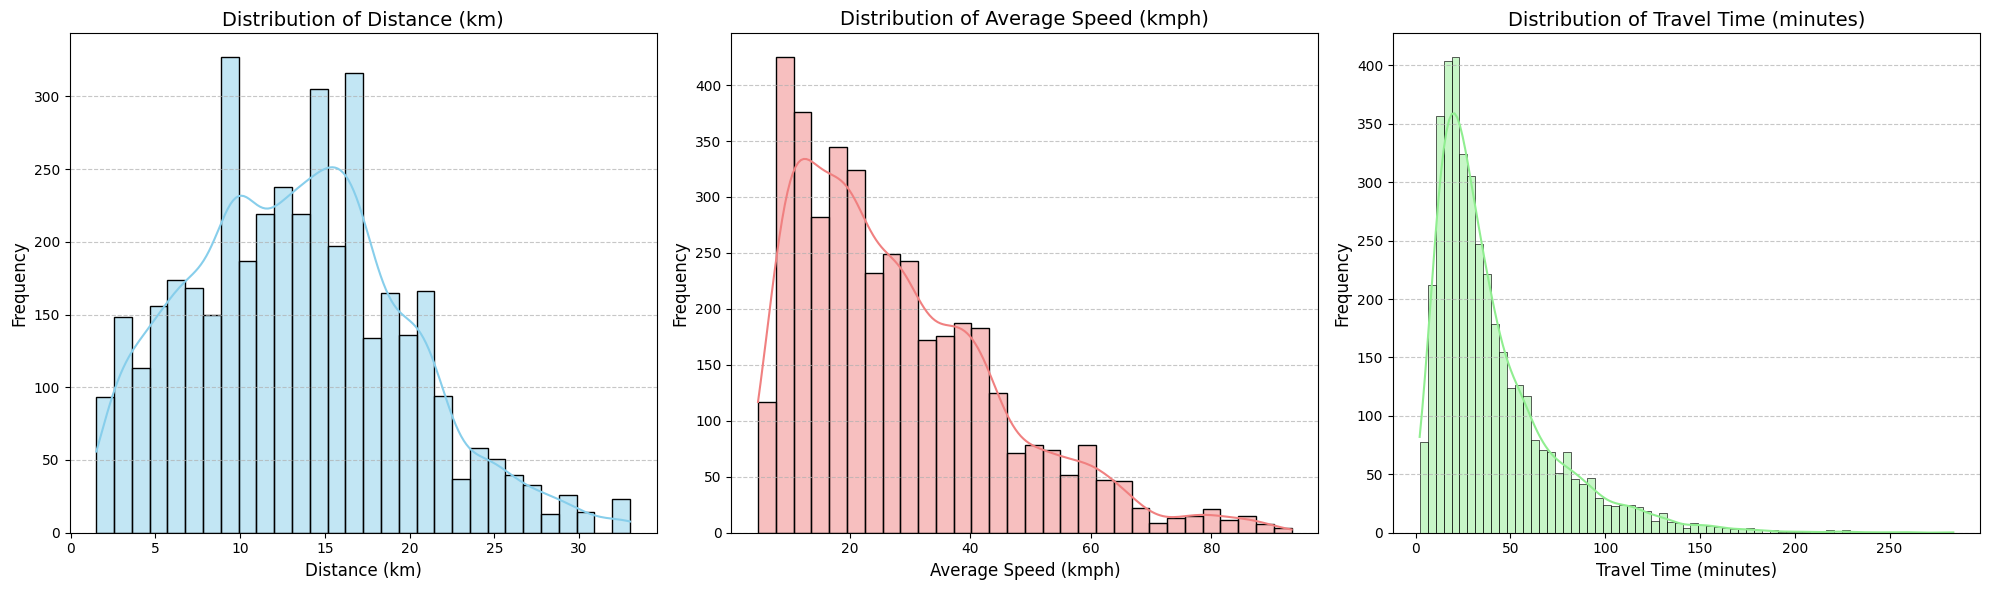

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(df['distance_km'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Distance (km)', fontsize=14)
axes[0].set_xlabel('Distance (km)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.histplot(df['average_speed_kmph'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Average Speed (kmph)', fontsize=14)
axes[1].set_xlabel('Average Speed (kmph)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

sns.histplot(df['travel_time_minutes'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Travel Time (minutes)', fontsize=14)
axes[2].set_xlabel('Travel Time (minutes)', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

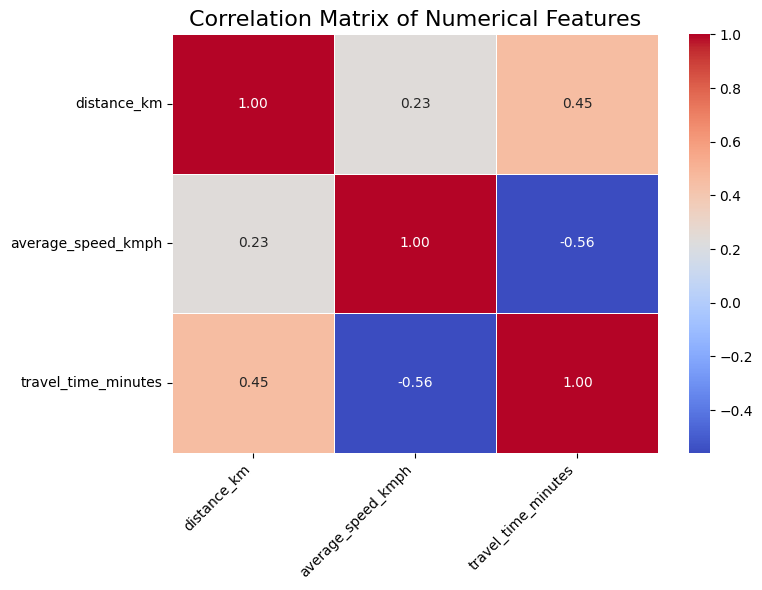

In [ ]:
numerical_cols = ['distance_km', 'average_speed_kmph', 'travel_time_minutes']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

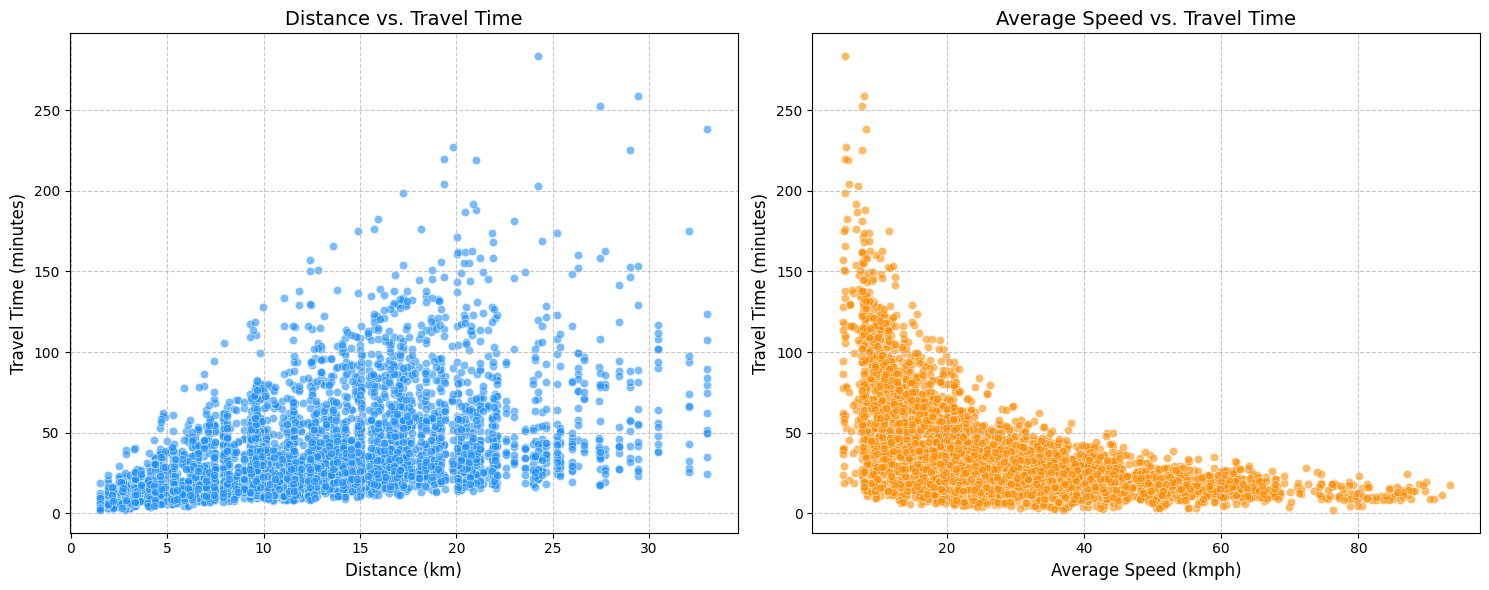

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(x='distance_km', y='travel_time_minutes', data=df, ax=axes[0], alpha=0.6, color='dodgerblue')
axes[0].set_title('Distance vs. Travel Time', fontsize=14)
axes[0].set_xlabel('Distance (km)', fontsize=12)
axes[0].set_ylabel('Travel Time (minutes)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.scatterplot(x='average_speed_kmph', y='travel_time_minutes', data=df, ax=axes[1], alpha=0.6, color='darkorange')
axes[1].set_title('Average Speed vs. Travel Time', fontsize=14)
axes[1].set_xlabel('Average Speed (kmph)', fontsize=12)
axes[1].set_ylabel('Travel Time (minutes)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Create 'is_peak_hour' feature
df['is_peak_hour'] = df['time_of_day'].apply(lambda x: 1 if 'Peak' in x else 0)

print("Count of 'is_peak_hour':")
print(df['is_peak_hour'].value_counts())

# 2. Create 'traffic_density_numeric' and interaction feature
traffic_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Very High': 4
}
df['traffic_density_numeric'] = df['traffic_density_level'].map(traffic_mapping)

df['distance_traffic_interaction'] = df['distance_km'] * df['traffic_density_numeric']

print("\nFirst 5 rows with new features:")
print(df[['time_of_day', 'is_peak_hour', 'traffic_density_level', 'traffic_density_numeric', 'distance_km', 'distance_traffic_interaction']].head())

Count of 'is_peak_hour':
is_peak_hour
1    2547
0    1453
Name: count, dtype: int64

First 5 rows with new features:
    time_of_day  is_peak_hour traffic_density_level  traffic_density_numeric  \
0         Night             0                   Low                        1   
1         Night             0                   Low                        1   
2  Morning Peak             1                  High                        3   
3         Night             0                   Low                        1   
4     Afternoon             0                Medium                        2   

   distance_km  distance_traffic_interaction  
0         9.44                          9.44  
1         2.15                          2.15  
2        14.54                         43.62  
3        11.86                         11.86  
4        20.26                         40.52  


In [ ]:
# --- Start: Initial Model Training and Evaluation (for comparison) ---
# This section is duplicated to ensure 'mae' and 'r2' from the initial model are always available for comparison.

categorical_features_original = [
    "start_area",
    "end_area",
    "time_of_day",
    "day_of_week",
    "weather_condition",
    "traffic_density_level",
    "road_type",
]
original_numerical_features = [
    "distance_km",
    "average_speed_kmph",
]

preprocessor_original = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_original)],
    remainder="passthrough",
)

X_original = df.drop(["travel_time_minutes", "Trip_ID", 'is_peak_hour', 'traffic_density_numeric', 'distance_traffic_interaction'], axis=1)
y_original = df["travel_time_minutes"]

X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_original, y_original, test_size=0.2, random_state=42
)

model_pipeline_original = Pipeline(
    steps=[
        ("preprocessor", preprocessor_original),
        ("regressor", LinearRegression()),
    ]
)
model_pipeline_original.fit(X_train_original, y_train_original)
y_pred_original = model_pipeline_original.predict(X_test_original)

mae = mean_absolute_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)
# ---------------------------------------------------


categorical_features_updated = [
    "start_area", "end_area", "time_of_day", "day_of_week",
    "weather_condition", "traffic_density_level", "road_type"
]

numerical_features_updated = [
    "distance_km", "average_speed_kmph", "is_peak_hour",
    "traffic_density_numeric", "distance_traffic_interaction"
]

# Create a column transformer for one-hot encoding categorical features
preprocessor_updated = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_updated),
        ('num', 'passthrough', numerical_features_updated)
    ]
)

# Define features (X_updated) and target (y)
X_updated = df.drop(["travel_time_minutes", "Trip_ID"], axis=1)
y = df["travel_time_minutes"]

# Split the data into training and testing sets
X_train_updated, X_test_updated, y_train, y_test = train_test_split(
    X_updated, y, test_size=0.2, random_state=42
)

# Create a pipeline with preprocessing and a linear regression model
model_pipeline_updated = Pipeline(
    steps=[
        ("preprocessor", preprocessor_updated),
        ("regressor", LinearRegression()),
    ]
)

# Train the updated model
model_pipeline_updated.fit(X_train_updated, y_train)

# Make predictions on the test set
y_pred_updated = model_pipeline_updated.predict(X_test_updated)

# Evaluate the updated model
mae_updated = mean_absolute_error(y_test, y_pred_updated)
mse_updated = mean_squared_error(y_test, y_pred_updated)
rmse_updated = np.sqrt(mse_updated)
r2_updated = r2_score(y_test, y_pred_updated)

print("\n--- Updated Model Evaluation (with new features) ---")
print(f"Mean Absolute Error (MAE): {mae_updated:.2f}")
print(f"Mean Squared Error (MSE): {mse_updated:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_updated:.2f}")
print(f"R-squared (R2): {r2_updated:.2f}")

print("\n--- Comparison with Previous Model ---")
print(f"Previous MAE: {mae:.2f}, New MAE: {mae_updated:.2f}")
print(f"Previous R2: {r2:.2f}, New R2: {r2_updated:.2f}")


--- Updated Model Evaluation (with new features) ---
Mean Absolute Error (MAE): 9.15
Mean Squared Error (MSE): 153.37
Root Mean Squared Error (RMSE): 12.38
R-squared (R2): 0.82

--- Comparison with Previous Model ---
Previous MAE: 10.05, New MAE: 9.15
Previous R2: 0.77, New R2: 0.82


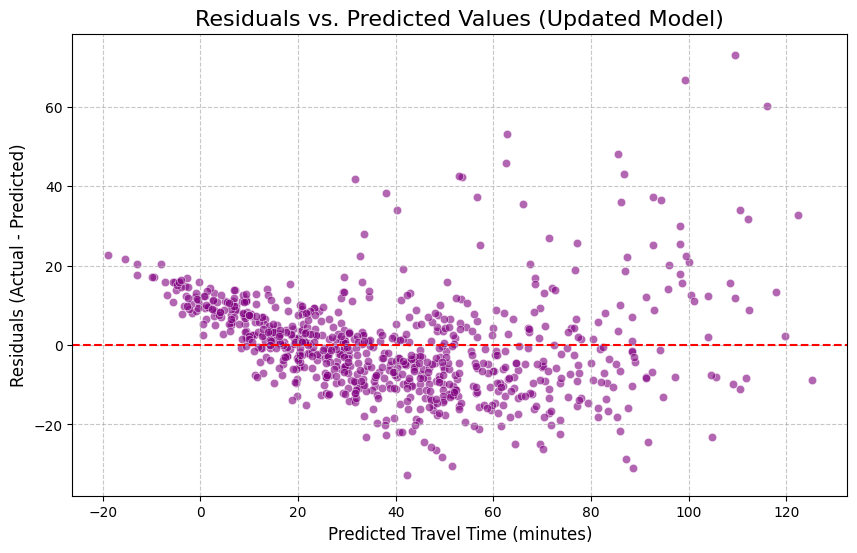

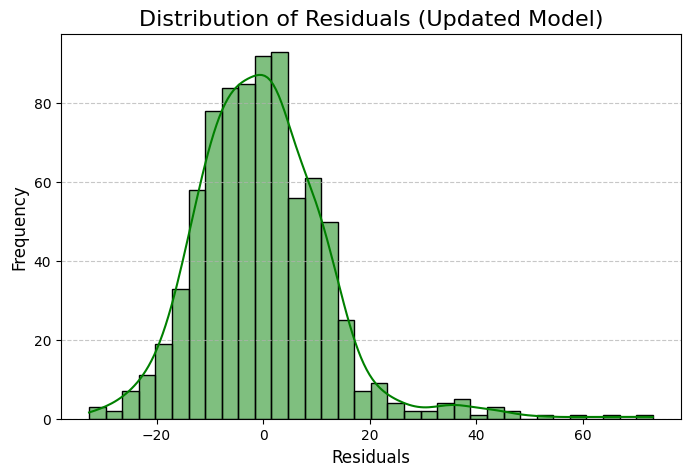

In [ ]:
residuals = y_test - y_pred_updated

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_updated, y=residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Updated Model)', fontsize=16)
plt.xlabel('Predicted Travel Time (minutes)', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='green')
plt.title('Distribution of Residuals (Updated Model)', fontsize=16)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print("\n--- Demonstrating Prediction on New Data ---")

# Create a hypothetical new trip's data
new_trip_data = pd.DataFrame({
    'start_area': ['Vasant Kunj', 'Janakpuri'],
    'end_area': ['Kalkaji', 'Model Town'],
    'distance_km': [10.0, 15.0],
    'time_of_day': ['Night', 'Morning Peak'],
    'day_of_week': ['Weekday', 'Weekday'],
    'weather_condition': ['Clear', 'Rain'],
    'traffic_density_level': ['Low', 'High'],
    'road_type': ['Main Road', 'Inner Road'],
    'average_speed_kmph': [40.0, 10.0]
})

# Manually add the engineered features to the new_trip_data
new_trip_data['is_peak_hour'] = new_trip_data['time_of_day'].apply(lambda x: 1 if 'Peak' in x else 0)

traffic_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Very High': 4
}
new_trip_data['traffic_density_numeric'] = new_trip_data['traffic_density_level'].map(traffic_mapping)
new_trip_data['distance_traffic_interaction'] = new_trip_data['distance_km'] * new_trip_data['traffic_density_numeric']

print("Hypothetical New Trip Data:")
print(new_trip_data)

# Use the trained pipeline to predict travel time for the new trip
predicted_travel_time = model_pipeline_updated.predict(new_trip_data)

print("\nPredicted Travel Times for New Trips:")
for i, pred_time in enumerate(predicted_travel_time):
    print(f"Trip {i+1}: {pred_time:.2f} minutes")


--- Demonstrating Prediction on New Data ---
Hypothetical New Trip Data:
    start_area    end_area  distance_km   time_of_day day_of_week  \
0  Vasant Kunj     Kalkaji         10.0         Night     Weekday   
1    Janakpuri  Model Town         15.0  Morning Peak     Weekday   

  weather_condition traffic_density_level   road_type  average_speed_kmph  \
0             Clear                   Low   Main Road                40.0   
1              Rain                  High  Inner Road                10.0   

   is_peak_hour  traffic_density_numeric  distance_traffic_interaction  
0             0                        1                          10.0  
1             1                        3                          45.0  

Predicted Travel Times for New Trips:
Trip 1: 5.18 minutes
Trip 2: 78.78 minutes


In [ ]:
# MAKING_VISUAL_FORMAT
# Weather vs Traffic
# --------------------------------------------------------------------------------------
df.groupby("weather_condition")["travel_time_minutes"].mean()

,travel_time_minutes
weather_condition,
Clear,34.969899
Fog,59.399027
Heatwave,38.033059
Rain,49.730050


In [ ]:
# MAKING OWN LOGIC
# The column 'traffic_volume' does not exist in df1.
# Please check the available columns or specify the correct column name.
# For example, you might want to use 'traffic_density_level' or 'average_speed_kmph'.
df1["congestion"] = np.where(df1["traffic_density_level"] == 'Very High', 1, 0) # Example using traffic_density_level

Columns in X after dropping Trip_ID: ['start_area', 'end_area', 'distance_km', 'time_of_day', 'day_of_week', 'weather_condition', 'traffic_density_level', 'road_type', 'average_speed_kmph', 'is_peak_hour', 'traffic_density_numeric', 'distance_traffic_interaction']

--- Model Evaluation ---
Mean Absolute Error (MAE): 9.15
Mean Squared Error (MSE): 153.37
Root Mean Squared Error (RMSE): 12.38
R-squared (R2): 0.82


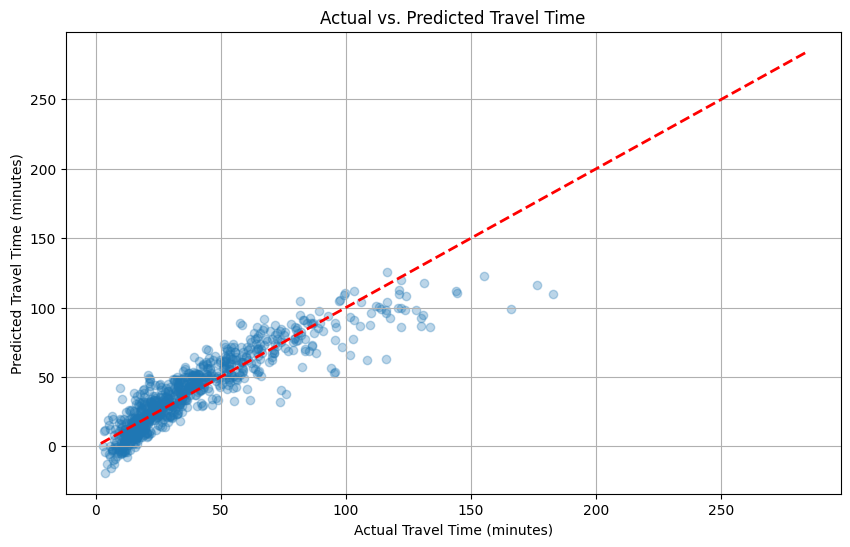

In [ ]:
# Identify categorical and numerical features
categorical_features = [
    "start_area",
    "end_area",
    "time_of_day",
    "day_of_week",
    "weather_condition",
    "traffic_density_level",
    "road_type",
]
numerical_features = [
    "distance_km",
    "average_speed_kmph",
]

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)],
    remainder="passthrough",  # Keep numerical features as they are
)

# Define features (X) and target (y)
# Drop 'Trip_ID' as it's an identifier and not a feature for prediction
X = df.drop(["travel_time_minutes", "Trip_ID"], axis=1)
y = df["travel_time_minutes"]

# Verify the columns in X after dropping Trip_ID
print("Columns in X after dropping Trip_ID:", X.columns.tolist())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create a pipeline with preprocessing and a linear regression model
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

# Train the model
model_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# You can also visualize actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Travel Time (minutes)')
plt.ylabel('Predicted Travel Time (minutes)')
plt.title('Actual vs. Predicted Travel Time')
plt.grid(True)
plt.show()

In [ ]:
# --- Start: Data Loading and Merging for Robustness ---
# This part ensures 'df' is defined if the kernel state was lost or cells were run out of order.
# The files are now present from previous executions and context.
df1 = pd.read_csv('/content/delhi_traffic_features.csv')
df2 = pd.read_csv('/content/delhi_traffic_target.csv')
df = pd.merge(df1, df2, on="Trip_ID")
# --- End: Data Loading and Merging ---

# --- Start: Feature Engineering (duplicated for robustness) ---
# This ensures the engineered features are present on 'df' before model training.
df['is_peak_hour'] = df['time_of_day'].apply(lambda x: 1 if 'Peak' in x else 0)

traffic_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Very High': 4
}
df['traffic_density_numeric'] = df['traffic_density_level'].map(traffic_mapping)
df['distance_traffic_interaction'] = df['distance_km'] * df['traffic_density_numeric']
# --- End: Feature Engineering ---

print("\n--- Consolidated Predictions for New Trips ---")

# --- Start: Code duplicated for robustness (model re-initialization) ---
# This part ensures model_pipeline_updated is defined and trained if the kernel state was lost.
# In a typical workflow, this model would be trained once in an earlier cell.

# Update categorical and numerical features lists to include new features
categorical_features_updated = [
    "start_area", "end_area", "time_of_day", "day_of_week",
    "weather_condition", "traffic_density_level", "road_type"
]
numerical_features_updated = [
    "distance_km", "average_speed_kmph", "is_peak_hour",
    "traffic_density_numeric", "distance_traffic_interaction"
]

preprocessor_updated = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_updated),
        ('num', 'passthrough', numerical_features_updated)
    ]
)

# Assuming 'df' is available and its engineered features have been added from previous cell executions.
# If 'df' is not defined, please ensure prior data loading and feature engineering cells are executed.
X_updated = df.drop(["travel_time_minutes", "Trip_ID"], axis=1)
y = df["travel_time_minutes"]

X_train_updated, _, y_train, _ = train_test_split(
    X_updated, y, test_size=0.2, random_state=42 # Only need X_train and y_train for fitting
)

model_pipeline_updated = Pipeline(
    steps=[
        ("preprocessor", preprocessor_updated),
        ("regressor", LinearRegression()),
    ]
)

model_pipeline_updated.fit(X_train_updated, y_train)
# --- End: Code duplicated for robustness ---


# Create a hypothetical new trip's data (moved from cell 90def94e)
new_trip_data = pd.DataFrame({
    'start_area': ['Panjabi Bagh', 'Rohini'],
    'end_area': ['Dwarka', 'Dwarka'],
    'distance_km': [11.86, 17.53],
    'time_of_day': ['Night', 'Morning Peak'],
    'day_of_week': ['Weekday', 'Weekday'],
    'weather_condition': ['Clear', 'Rain'],
    'traffic_density_level': ['Low', 'High'],
    'road_type': ['Main Road', 'Inner Road'],
    'average_speed_kmph': [40.0, 10.0]
})

# Manually add the engineered features to the new_trip_data (moved from cell 90def94e)
new_trip_data['is_peak_hour'] = new_trip_data['time_of_day'].apply(lambda x: 1 if 'Peak' in x else 0)

traffic_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Very High': 4
}
new_trip_data['traffic_density_numeric'] = new_trip_data['traffic_density_level'].map(traffic_mapping)
new_trip_data['distance_traffic_interaction'] = new_trip_data['distance_km'] * new_trip_data['traffic_density_numeric']

# Use the trained pipeline to predict travel time for the new trip
predicted_travel_time = model_pipeline_updated.predict(new_trip_data)

# Create a DataFrame to display the new trip data along with their predictions
predictions_df = new_trip_data.copy()
predictions_df['predicted_travel_time_minutes'] = predicted_travel_time

# Select and display relevant columns for a concise summary
print(predictions_df[['start_area', 'end_area', 'distance_km', 'time_of_day', 'weather_condition', 'predicted_travel_time_minutes']].to_markdown(index=False))


--- Consolidated Predictions for New Trips ---
| start_area   | end_area   |   distance_km | time_of_day   | weather_condition   |   predicted_travel_time_minutes |
|:-------------|:-----------|--------------:|:--------------|:--------------------|--------------------------------:|
| Panjabi Bagh | Dwarka     |         11.86 | Night         | Clear               |                         13.113  |
| Rohini       | Dwarka     |         17.53 | Morning Peak  | Rain                |                         78.9322 |
